In [29]:
import os
import random
from graphviz import Digraph
from IPython.display import Image, display


class Node:
    def __init__(self, key):
        self.key = key
        self.size = 1  #*
        self.color = 0
        self.p = None
        self.left = None
        self.right = None


RED = 0
BLACK = 1
NIL = Node(None)
NIL.color = BLACK
NIL.size = 0  #*


class RBTree:
    def __init__(self):
        self.root = NIL

    def right_rotate(self, y):
        """右旋操作"""
        x = y.left
        beta = x.right
        pNode = y.p

        # 连接下级结点beta
        y.left = beta
        if beta != NIL:
            beta.p = y

        # 连接上级结点pNode
        x.p = pNode
        if pNode == NIL:
            self.root = x
        elif pNode.left == y:
            pNode.left = x
        else:
            pNode.right = x

        # 连接结点x和y
        x.right = y
        y.p = x

        #* 更新size
        x.size = y.size
        y.size = y.left.size + y.right.size + 1

    def left_rotate(self, x):
        """左旋操作"""
        y = x.right
        beta = y.left
        pNode = x.p

        # 连接下级结点beta
        x.right = beta
        if beta != NIL:
            beta.p = x

        # 连接上级结点pNode
        y.p = pNode
        if pNode == NIL:
            self.root = y
        elif pNode.left == x:
            pNode.left = y
        else:
            pNode.right = y

        # 连接结点x和y
        y.left = x
        x.p = y

        #* 更新size
        y.size = x.size
        x.size = x.left.size + x.right.size + 1

    def search(self, key):
        """搜索带有键的结点"""
        node = self.root
        while node != NIL:
            if key < node.key:
                node = node.left
            elif key > node.key:
                node = node.right
            else:
                return node
        return NIL

    def insert(self, key):
        """插入带有键的结点"""
        pNode = NIL
        node = self.root

        path = [] #*

        # 搜索直到匹配结点, 或者空结点
        while node != NIL:
            pNode = node
            path.append(pNode)
            if key < node.key:
                node = node.left
            elif key > node.key:
                node = node.right
            else:
                return
            
        #* 更新路径结点的size
        for node in path:
            node.size += 1

        # 建立当前结点的向上连接
        iNode = Node(key)
        iNode.p = pNode

        # 建立父结点的向下连接
        if pNode == NIL:
            self.root = iNode
        elif key < pNode.key:
            pNode.left = iNode
        else:
            pNode.right = iNode

        # 初始化为末尾红色结点
        iNode.left = NIL
        iNode.right = NIL
        iNode.color = RED

        self.insert_fixup(iNode)

    def insert_fixup(self, node):
        """插入调整"""
        # 此时node为红色, 如果父也是红色
        while node.p.color == RED:
            # 如果父是祖父的左结点
            if node.p == node.p.p.left:
                uncle = node.p.p.right

                # 如果叔结点为红色
                # 叔与父变黑, 祖父变红 且继续处理
                if uncle.color == RED:
                    node.p.color = BLACK
                    uncle.color = BLACK
                    node.p.p.color = RED
                    node = node.p.p

                # 如果叔结点为黑色
                # 旋转, 使红点分居两侧
                else:
                    if node == node.p.right:
                        node = node.p
                        self.left_rotate(node)
                    node.p.color = BLACK
                    node.p.p.color = RED
                    self.right_rotate(node.p.p)

            # 如果父是祖父的右结点
            else:
                uncle = node.p.p.left

                # 如果叔结点为红色
                # 叔与父变黑, 祖父变红 且继续处理
                if uncle.color == RED:
                    node.p.color = BLACK
                    uncle.color = BLACK
                    node.p.p.color = RED
                    node = node.p.p

                # 如果叔结点为黑色
                # 旋转, 使红点分居两侧
                else:
                    if node == node.p.left:
                        node = node.p
                        self.right_rotate(node)
                    node.p.color = BLACK
                    node.p.p.color = RED
                    self.left_rotate(node.p.p)

        # 最后将根结点变黑
        self.root.color = BLACK

    def _transplant(self, old, new):
        """移动替换整棵子树"""
        # 更新当前结点的向上连接
        new.p = old.p

        # 更新父结点的向下连接
        if old.p == NIL:
            self.root = new
        elif old == old.p.left:
            old.p.left = new
        else:
            old.p.right = new

    def _minimum(self, node):
        """返回子树的最小结点"""
        while node.left != NIL:
            node = node.left
        return node

    def delete(self, key):
        """删除键对应的结点"""
        node = self.search(key)

        # 记录删除结点的颜色
        delete_color = node.color

        # 如果左结点为空, 则用右结点替换
        if node.left == NIL:
            new = node.right
            self._transplant(node, node.right)

        # 如果右结点为空, 则用左结点替换
        elif node.right == NIL:
            new = node.left
            self._transplant(node, node.left)

        # 如果左右子树都不空, 则替换并移除后继
        else:
            nxt = self._minimum(node.right)
            delete_color = nxt.color
            new = nxt.right

            # NIL结点向上连接
            if new == NIL:
                new.p = nxt

            # 如果后继不是直接子结点
            # 则先要移交后继结点的右子树
            if nxt.p != node:
                self._transplant(nxt, nxt.right)
                nxt.right = node.right
                nxt.right.p = nxt
            self._transplant(node, nxt)
            nxt.left = node.left
            nxt.left.p = nxt
            # 切换为node的颜色
            nxt.color = node.color
            #* 切换size
            nxt.size = node.size

        #* 更新路径结点的size
        node = new.p
        while node != NIL:
            node.size -= 1
            node = node.p

        # 如果删除的是黑点, 则需要调整
        if delete_color == BLACK:
            self.delete_fixup(new)

    def delete_fixup(self, node):
        """删除调整"""

        while node != self.root and node.color == BLACK:

            # 如果当前结点是左结点
            if node == node.p.left:
                bro = node.p.right

                ## 如果兄弟结点是红色
                ## 左旋 使父变红-兄弟变黑
                if bro.color == RED:
                    bro.color = BLACK
                    node.p.color = RED
                    self.left_rotate(node.p)
                    bro = node.p.right

                ## 如果兄弟结点 只有黑子结点
                ## 兄弟变红, 将黑缺口上移
                if bro.left.color == BLACK and bro.right.color == BLACK:
                    bro.color = RED
                    node = node.p

                ## 如果兄弟结点 有红子节点
                else:
                    ### 如果右子节点为黑
                    ### 右旋 使得兄弟有右红结点
                    if bro.right.color == BLACK:
                        bro.left.color = BLACK
                        bro.color = RED
                        self.right_rotate(bro)
                        bro = node.p.right

                    ### 左旋 从兄弟的右红-借黑
                    bro.color = node.p.color
                    node.p.color = BLACK
                    bro.right.color = BLACK
                    self.left_rotate(node.p)
                    node = self.root

            # 如果当前结点是右结点
            else:
                bro = node.p.left

                ## 如果兄弟结点是红色
                ## 右旋 使父变红-兄弟变黑
                if bro.color == RED:
                    bro.color = BLACK
                    node.p.color = RED
                    self.right_rotate(node.p)
                    bro = node.p.left

                ## 如果兄弟结点 只有黑子结点
                ## 兄弟变红, 将黑缺口上移
                if bro.right.color == BLACK and bro.left.color == BLACK:
                    bro.color = RED
                    node = node.p

                ## 如果兄弟结点 有红子节点
                else:
                    ### 如果左子节点为黑
                    ### 左旋 使得兄弟有左红结点
                    if bro.left.color == BLACK:
                        bro.right.color = BLACK
                        bro.color = RED
                        self.left_rotate(bro)
                        bro = node.p.left

                    ### 右旋 从兄弟的左红-借黑
                    bro.color = node.p.color
                    node.p.color = BLACK
                    bro.left.color = BLACK
                    self.right_rotate(node.p)
                    node = self.root

        # 如果是红点, 则直接变黑抵消
        # 如果是根结点, 则可直接变黑
        node.color = BLACK


    def order_select(self, node, k): #*
        """返回sorted(node)[k]"""
        r = node.left.size
        if k == r:
            return node
        elif k < r:
            return self.order_select(node.left, k)
        else:
            return self.order_select(node.right, k - r - 1)
        
    def order_rank(self, node): #*
        """返回sorted(node).index(node)"""
        r = node.left.size
        y = node
        while y != self.root:
            if y == y.p.right:
                r = r + y.p.left.size + 1
            y = y.p
        return r

    def draw_tree(self, dot: Digraph = None, node=None):
        """绘制红黑树"""
        if dot is None:
            # 初始化图
            dot = Digraph()
            dot.attr("node", shape="circle")
            dot.attr("edge", dir="none")

            # 递归添加每层的结点和边
            self.draw_tree(dot, self.root)

            # 渲染并显示图像
            dot.render("bst", format="png", cleanup=True)
            display(Image("bst.png"))
            os.remove("bst.png")
        else:
            if node != NIL:
                str_node = str(node.key)
                color = "lightcoral" if node.color == RED else ""
                dot.node(str_node, str_node + f"\n[{node.size}]", style="filled", fillcolor=color)
                if node.left != NIL:
                    str_left = str(node.left.key)
                    dot.edge(str_node, str_left, constraint="true")
                    self.draw_tree(dot, node.left)
                else:
                    dot.node(str_node + "L", "", shape="point")
                    dot.edge(str_node, str_node + "L", constraint="true")
                if node.right != NIL:
                    str_right = str(node.right.key)
                    dot.edge(str_node, str_right, constraint="true")
                    self.draw_tree(dot, node.right)
                else:
                    dot.node(str_node + "R", "", shape="point")
                    dot.edge(str_node, str_node + "R", constraint="true")

key=67
7
7


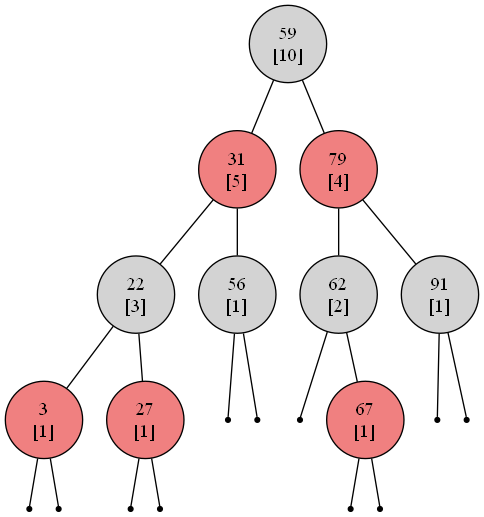

In [33]:
rbt = RBTree()
dct = {}
arr = []

for _ in range(10):
    key = random.randint(0, 100)
    rbt.insert(key)
    dct[key] = 1
    if key not in arr:
        arr.append(key)


key = random.choice(arr)
node = rbt.search(key)

print(f"key={key}")
print(sorted(arr).index(key))
print(rbt.order_rank(node))

rbt.draw_tree()


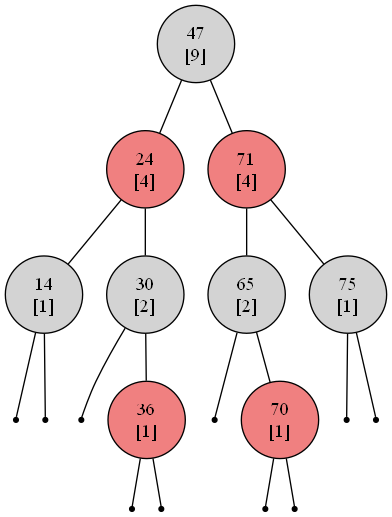